# 08 — The Steelrunner

Steel feruchemy stores **physical speed** (canon, Coppermind): tapping moves
the body many times faster — outpacing even duralumin-fueled pewter — and
storing leaves the Ferring sluggish, *"like moving through molasses."*

The question this notebook exists to answer: **is a Steelrunner just a
personal bendalloy bubble?** No — and the difference is now measurable.
A bubble rescales your entire local clock (healing, poison, aging included)
and, by the when-not-where theorem (notebook 07), can never add velocity.
F-steel taxes or amplifies the body's *mechanical output* — real kinetic
state the world keeps — while internal chemistry ticks at the normal rate.
The handwaive boundary sits at the skin: your muscles produce kinetics less
or more efficiently, but locally you're still doing the same equations, and
your heartbeat is none of the magic's business (canon is silent on the
pulse; we model the tidy, respectable boundary).

New machinery: `sim/locomotion.py` — Legs, the sim's first self-propulsion.
Legs drive a grounded body toward a target speed, stop driving in the air
(what you leave the ground with is what you fly with), and expose the
`speed_multiplier` dial that `SteelFeruchemy` turns. Zero-sum bookkeeping in
*speed-seconds*: one second of full normal speed forgone or regained.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import (Body, World, Health, Poison, SpeedBubble,
                 Legs, SteelFeruchemy)


def make_runner(world, tap=None, store=None, reserve=500.0):
    body = world.add_body(Body("runner", 80, (0, 0.3)))
    legs = world.add_power(Legs(body, top_speed_m_per_s=8))
    steelmind = SteelFeruchemy(legs, initial_reserve_speed_seconds=reserve)
    world.powers.insert(0, steelmind)  # multiplier set before legs read it
    if tap is not None:
        steelmind.tap(tap)
    if store is not None:
        steelmind.store(store)
    legs.direction = 1
    return body, legs, steelmind

## Experiment A — the footrace

Three identical runners (8 m/s legs): one normal, one tapping +4 (five times
speed), one storing half (the molasses years).

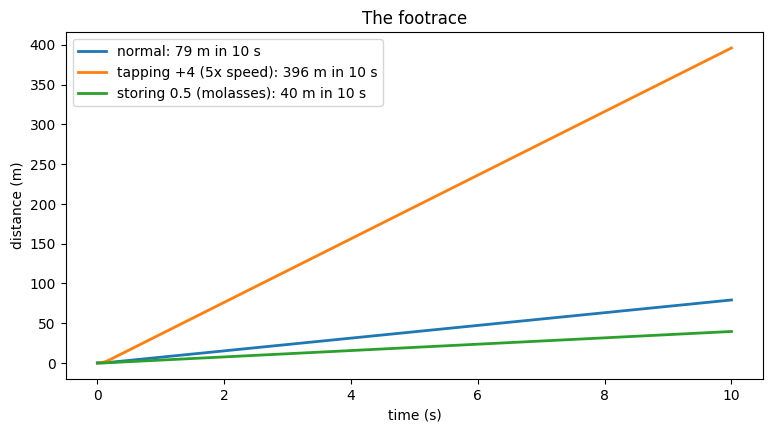

In [2]:
figure, ax = plt.subplots(figsize=(9, 4.5))

for label, kwargs in [("normal", {}), ("tapping +4 (5x speed)", {"tap": 4.0}),
                      ("storing 0.5 (molasses)", {"store": 0.5})]:
    world = World()
    body, _, _ = make_runner(world, **kwargs)
    world.run(10.0)
    data = world.history.body("runner")
    ax.plot(data["t"], data["x"], linewidth=2,
            label=f"{label}: {data['x'][-1]:.0f} m in 10 s")

ax.set_xlabel("time (s)")
ax.set_ylabel("distance (m)")
ax.set_title("The footrace")
ax.legend(loc="upper left")
plt.show()

## Experiment B — the steelmind runs dry mid-stride

Zero-sum on screen: store half your speed for 10 seconds (banking exactly 5
speed-seconds of misery-jogging), then tap +4 — which drains 4 per second.
That buys 1.25 seconds of glory, and then the dial snaps back to 1 mid-run.

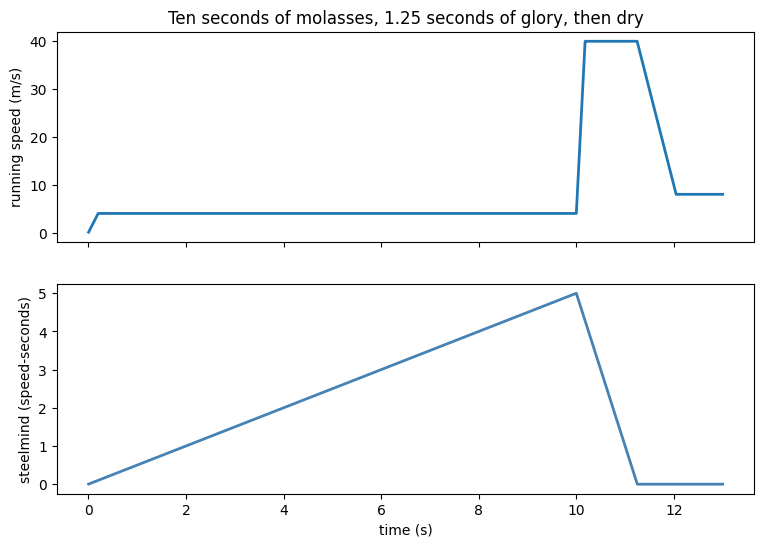

final speed 8.0 m/s, steelmind 0.00


In [3]:
world = World()
body, legs, steelmind = make_runner(world, reserve=0.0)

times, speed, banked = [], [], []
steelmind.store(0.5)
for _ in range(int(10.0 / world.dt_seconds)):
    world.step(); times.append(world.time_seconds)
    speed.append(legs.current_speed); banked.append(steelmind.reserve_speed_seconds)
steelmind.tap(4.0)
for _ in range(int(3.0 / world.dt_seconds)):
    world.step(); times.append(world.time_seconds)
    speed.append(legs.current_speed); banked.append(steelmind.reserve_speed_seconds)

figure, (ax_speed, ax_bank) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax_speed.plot(times, speed, linewidth=2)
ax_speed.set_ylabel("running speed (m/s)")
ax_speed.set_title("Ten seconds of molasses, 1.25 seconds of glory, then dry")
ax_bank.plot(times, banked, color="steelblue", linewidth=2)
ax_bank.set_ylabel("steelmind (speed-seconds)")
ax_bank.set_xlabel("time (s)")
plt.show()

print(f"final speed {legs.current_speed:.1f} m/s, steelmind {steelmind.reserve_speed_seconds:.2f}")

## Experiment C — a Steelrunner is not a bubble (the chemistry test)

Two men, both poisoned at 5 HP/s, both "moving at five times speed": one is
a Steelrunner tapping +4, the other a normal man inside a 5× bendalloy
bubble. If steel were a personal bubble, both would die at 4 external
seconds. Canon (and our model) says the Steelrunner's blood is none of the
steel's business — he dies on the normal 20-second schedule, sprinting.

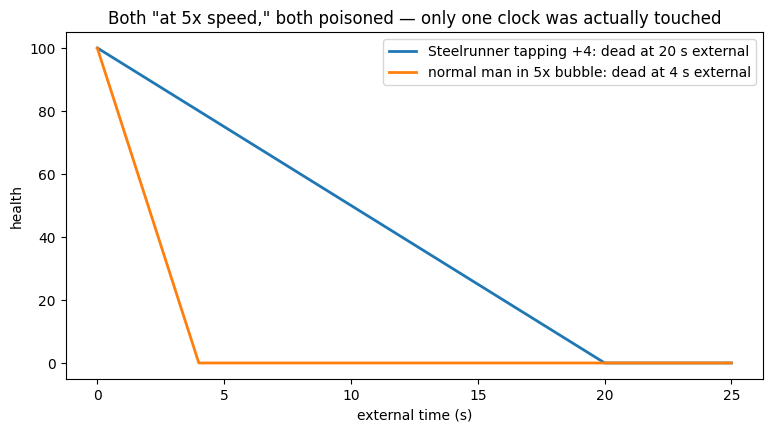

In [4]:
figure, ax = plt.subplots(figsize=(9, 4.5))

world_steel = World()
runner, _, _ = make_runner(world_steel, tap=4.0)
steel_health = world_steel.add_power(Health(runner, 100, natural_regen_per_second=0))
world_steel.add_power(Poison(steel_health, damage_per_second=5))

world_bubble = World()
bystander = world_bubble.add_body(Body("man", 80, (0, 0.3)))
bubble_health = world_bubble.add_power(Health(bystander, 100, natural_regen_per_second=0))
world_bubble.add_power(Poison(bubble_health, damage_per_second=5))
world_bubble.add_bubble(SpeedBubble(center=(0, 0.3), radius_m=2, time_factor=5.0))

for label, world, health in [("Steelrunner tapping +4", world_steel, steel_health),
                             ("normal man in 5x bubble", world_bubble, bubble_health)]:
    times, hp = [], []
    for _ in range(int(25.0 / world.dt_seconds)):
        world.step(); times.append(world.time_seconds); hp.append(health.current)
    hp = np.array(hp)
    death = np.array(times)[np.argmax(hp <= 0)]
    ax.plot(times, hp, linewidth=2, label=f"{label}: dead at {death:.0f} s external")

ax.set_xlabel("external time (s)")
ax.set_ylabel("health")
ax.set_title('Both "at 5x speed," both poisoned — only one clock was actually touched')
ax.legend(loc="upper right")
plt.show()

## Experiment D — the long jump (kinetic state is kept)

The other half of the distinction. Three runners sprint 30 m and leap with
the same upward kick:

1. **Plain** — leaves the ground at 8 m/s.
2. **Steelrunner tapping +4** — leaves at 40 m/s of *real* velocity.
3. **Plain runner whose runway and takeoff sit inside a 5× bendalloy
   bubble** — looks just as fast from outside while in the bubble, but his
   velocity *state* is still 8 m/s, and the when-not-where theorem says the
   bubble cannot change where his arc lands.

A bubble reschedules. Steel adds. The sand pit knows the difference.

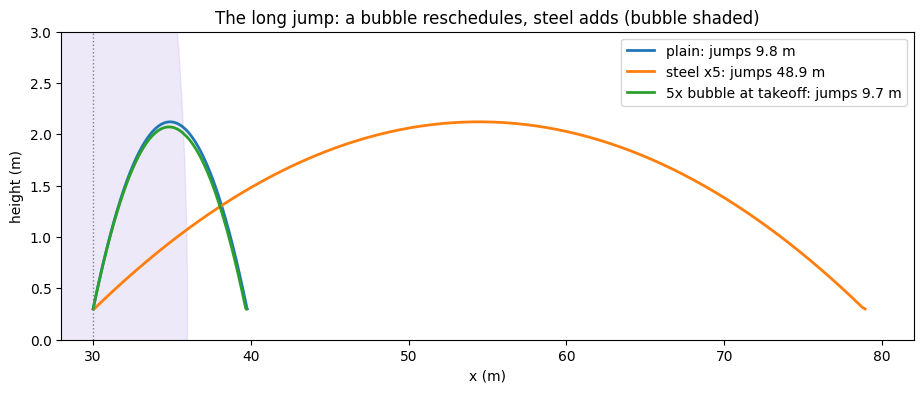

In [5]:
def long_jump(label, tap=None, bubble=False):
    world = World()
    body, legs, _ = make_runner(world, tap=tap)
    if bubble:
        world.add_bubble(SpeedBubble(center=(30, 0.3), radius_m=6, time_factor=5.0))
    while body.position[0] < 30:
        world.step()
    legs.jump(6.0)
    world.step()
    while not body.on_ground:
        world.step()
    return world.history.body("runner"), body.position[0] - 30

figure, ax = plt.subplots(figsize=(11, 4))
ax.add_patch(plt.Circle((30, 0.3), 6, color="mediumpurple", alpha=0.15))
for label, kwargs in [("plain", {}), ("steel x5", {"tap": 4.0}),
                      ("5x bubble at takeoff", {"bubble": True})]:
    data, jump_range = long_jump(label, **kwargs)
    airborne = data["x"] >= 30
    ax.plot(data["x"][airborne], data["y"][airborne], linewidth=2,
            label=f"{label}: jumps {jump_range:.1f} m")

ax.axvline(30, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("x (m)"); ax.set_ylabel("height (m)")
ax.set_title("The long jump: a bubble reschedules, steel adds (bubble shaded)")
ax.legend()
ax.set_xlim(28, 82); ax.set_ylim(0, 3)
plt.show()

## Findings

1. **The footrace is exact**: 5× distance tapping +4, half distance storing
   0.5, and the steelmind's books balance to the hundredth of a
   speed-second — ten seconds of molasses buys 1.25 seconds of glory.
2. **A Steelrunner is not a personal bubble, measurably.** Same "5× speed"
   label, same poison: the Steelrunner dies at 20 s (his blood never heard
   about the steel), the bubble man at 4 s (his whole clock was compressed).
   Elliott's handwaive boundary — the magic stops at the skin — is now an
   architectural fact: `SteelFeruchemy` touches only `Legs`, never `Health`.
3. **Steel velocity is real and bubbles' isn't.** The steel leap carries
   48.9 m; the bubble-assisted leap lands at 9.7 m — within centimeters of
   the plain 9.8 m, exactly as the when-not-where theorem demands. A bubble
   can make you *arrive* sooner; only steel can make you *fly* farther.
4. **Tactical corollary**: F-steel output is exportable (leaps, thrown
   punches, projectiles launched by hand); bubble speed is confined to the
   fence. The Wax-vs-Wayne mobility comparison the original idea doc asked
   about now has its vocabulary.
5. **Next candidates**: pewter (needs an exertion/durability model), the
   two-point rigid bullet (bubble boundary shear — the deflection test),
   or atium.